# Modelowanie

Trenujemy dwa modele do predykcji rezerwacji po obejrzeniu oferty:

- **model A (bazowy):** regresja logistyczna,
- **model B (docelowy):** las losowy.

Oba trafią później do mikroserwisu w eksperymencie A/B. Wynik modelu ma być dodatkowym składnikiem rankingu:

$$FinalScore = W_A \times BaseScore + W_B \times P(Y=1|X)$$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, f1_score, precision_score, recall_score
)
import joblib

df = pd.read_csv("../data/processed/training_data.csv")
print(f"Dataset: {df.shape}")
df.head()

Dataset: (317277, 28)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


## Przygotowanie danych

Usuwamy kolumny identyfikacyjne, oddzielamy `Y` od cech i jeszcze raz sprawdzamy braki danych.


In [ ]:
drop_cols = ['user_id', 'timestamp', 'listing_id']
df = df.drop(columns=drop_cols)

y = df['Y']
X = df.drop(columns=['Y'])

# Identify column types
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
num_cols = [c for c in X.columns if c not in cat_cols]

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna('Unknown')

print(f"Features: {X.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Categorical cardinalities: {', '.join(f'{c}={X[c].nunique()}' for c in cat_cols)}")
print(f"Missing values: {X.isnull().sum().sum()}")
X.head()

Features: 24 (21 numeric, 3 categorical)
Categorical cardinalities: property_type=9, room_type=5, neighbourhood_cleansed=12
Missing values: 0


,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,alltime_review_scores_accuracy,alltime_review_scores_rating,alltime_review_count,recent_review_scores_cleanliness,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


In [3]:
# Train / test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train Y=1 ratio: {y_train.mean():.4f}")
print(f"Test  Y=1 ratio: {y_test.mean():.4f}")

Train: (253821, 24), Test: (63456, 24)
Train Y=1 ratio: 0.0073
Test  Y=1 ratio: 0.0073


## Kodowanie cech

Kategorie zamieniamy na one-hot. Skaler przygotowujemy głównie dla regresji logistycznej; modele drzewiaste nie wymagają skalowania.


In [4]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

scaler = StandardScaler()
scaler.fit(X_train[num_cols])


def encode_features(X_df, scale=False):
    """Encode categoricals and optionally scale numerics."""
    X_num = X_df[num_cols].copy()
    if scale:
        X_num = scaler.transform(X_num)
    else:
        X_num = X_num.values
    X_cat = encoder.transform(X_df[cat_cols])
    return np.hstack([X_num, X_cat])


feature_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))

X_train_enc = encode_features(X_train)
X_test_enc = encode_features(X_test)
X_train_scaled = encode_features(X_train, scale=True)
X_test_scaled = encode_features(X_test, scale=True)

print(f"Encoded features: {len(feature_names)}")
print(f"Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")
print(f"One-hot categories: {encoder.get_feature_names_out(cat_cols).tolist()}")

Encoded features: 47
Train: (253821, 47), Test: (63456, 47)
One-hot categories: ['property_type_Entire condo', 'property_type_Entire home', 'property_type_Entire rental unit', 'property_type_Entire townhouse', 'property_type_Entire villa', 'property_type_Other', 'property_type_Private room in condo', 'property_type_Private room in rental unit', 'property_type_Unknown', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'room_type_Unknown', 'neighbourhood_cleansed_Amager Vest', 'neighbourhood_cleansed_Amager st', 'neighbourhood_cleansed_Bispebjerg', 'neighbourhood_cleansed_Brnshj-Husum', 'neighbourhood_cleansed_Frederiksberg', 'neighbourhood_cleansed_Indre By', 'neighbourhood_cleansed_Nrrebro', 'neighbourhood_cleansed_Unknown', 'neighbourhood_cleansed_Valby', 'neighbourhood_cleansed_Vanlse', 'neighbourhood_cleansed_Vesterbro-Kongens Enghave', 'neighbourhood_cleansed_sterbro']


## Trenowanie modeli

Trenujemy dwa modele z `class_weight='balanced'`, bo rezerwacji jest bardzo mało.


In [5]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (neg/pos): {scale_pos:.1f}")

models = {
    'A_LogisticRegression': LogisticRegression(
        max_iter=2000, random_state=42, class_weight='balanced'
    ),
    'B_RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
    ),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")

    if name == 'A_LogisticRegression':
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_enc, X_test_enc

    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
    }
    print(
        f"  ROC-AUC: {results[name]['roc_auc']:.4f}, "
        f"AP: {results[name]['avg_precision']:.4f}, "
        f"F1: {results[name]['f1']:.4f}"
    )

Imbalance ratio (neg/pos): 136.7
Training A_LogisticRegression...


  ROC-AUC: 0.6813, AP: 0.0256, F1: 0.0350
Training B_RandomForest...


  ROC-AUC: 0.6998, AP: 0.0282, F1: 0.0432


## Ocena modeli

Porównujemy oba modele na zbiorze testowym. Patrzymy głównie na ROC-AUC i Average Precision - rezerwacji jest mało.


In [6]:
metrics_df = pd.DataFrame({
    name: {
        'ROC-AUC': res['roc_auc'],
        'Average Precision': res['avg_precision'],
        'precision': res['precision'],
        'recall': res['recall'],
        'F1': res['f1'],
    }
    for name, res in results.items()
}).T
print("Porównanie metryk:")
display(metrics_df.round(4))

for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"{name}  (ROC-AUC: {res['roc_auc']:.4f})")
    print('='*60)
    print(classification_report(y_test, res['y_pred'], target_names=['No Booking', 'Booking']))

Porównanie metryk:


,ROC-AUC,Average Precision,precision,recall,F1
A_LogisticRegression,0.6813,0.0256,0.0182,0.4816,0.0350
B_RandomForest,0.6998,0.0282,0.0228,0.3948,0.0432



A_LogisticRegression  (ROC-AUC: 0.6813)
              precision    recall  f1-score   support

  No Booking       1.00      0.81      0.89     62995
     Booking       0.02      0.48      0.03       461

    accuracy                           0.81     63456
   macro avg       0.51      0.65      0.46     63456
weighted avg       0.99      0.81      0.89     63456


B_RandomForest  (ROC-AUC: 0.6998)
              precision    recall  f1-score   support

  No Booking       0.99      0.88      0.93     62995
     Booking       0.02      0.39      0.04       461

    accuracy                           0.87     63456
   macro avg       0.51      0.64      0.49     63456
weighted avg       0.99      0.87      0.93     63456



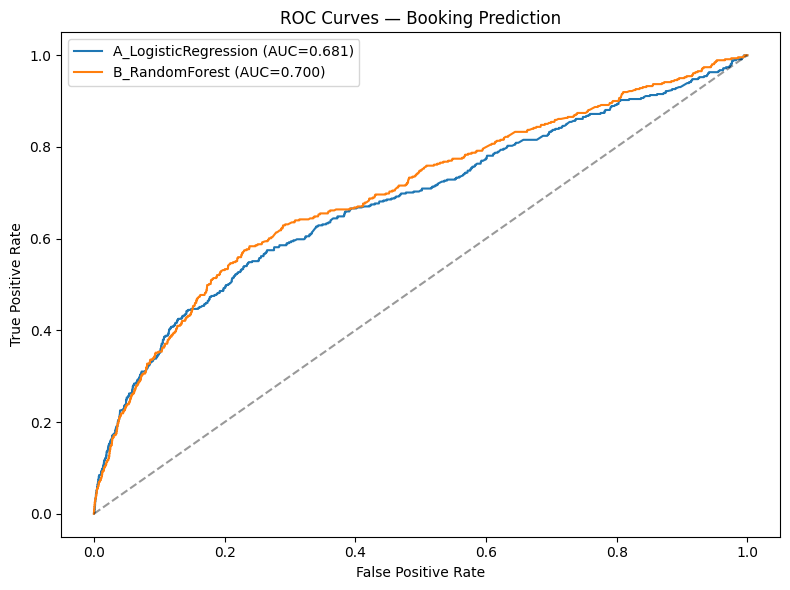

In [ ]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Booking Prediction')
ax.legend()
plt.tight_layout()
plt.show()

## Ważność cech

Dla modelu B (las losowy) sprawdzamy, które cechy miały największy wpływ na predykcję.


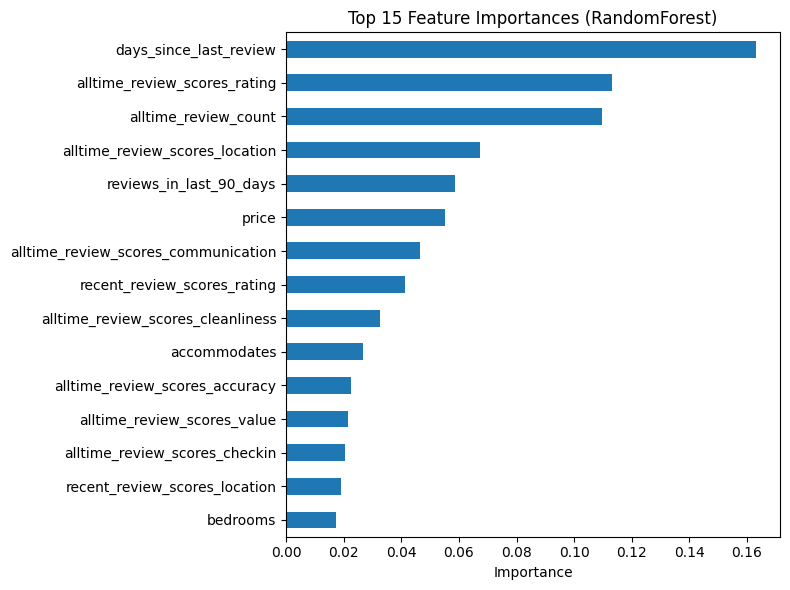

In [8]:
target_model = results['B_RandomForest']['model']

importances = pd.Series(target_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.plot(kind='barh', ax=ax)
ax.set_title('Top 15 Feature Importances (RandomForest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Predykcje i zapis artefaktów

Sprawdzamy predykcje na przykładowych danych z ostatnich 30 dni. Zapisujemy oba modele i wspólny preprocessing.


In [9]:
inference_df = pd.read_csv("../data/processed/inference_sample.csv")
inf_ids = inference_df[['user_id', 'timestamp', 'listing_id']].copy()
inf_X = inference_df.drop(columns=['user_id', 'timestamp', 'listing_id', 'Y'], errors='ignore')

inf_X[num_cols] = inf_X[num_cols].fillna(inf_X[num_cols].median())
inf_X[cat_cols] = inf_X[cat_cols].fillna('Unknown')

baseline_model = results['A_LogisticRegression']['model']
target_model = results['B_RandomForest']['model']

inf_scaled = encode_features(inf_X, scale=True)
inf_encoded = encode_features(inf_X, scale=False)

inf_ids['prob_model_A'] = baseline_model.predict_proba(inf_scaled)[:, 1]
inf_ids['prob_model_B'] = target_model.predict_proba(inf_encoded)[:, 1]

print(f"Predykcje inferencyjne: {inf_ids.shape}")
print("\nRozkład prawdopodobieństw (model A):")
print(inf_ids['prob_model_A'].describe())
print("\nRozkład prawdopodobieństw (model B):")
print(inf_ids['prob_model_B'].describe())
inf_ids.sort_values('prob_model_B', ascending=False).head(10)

Predykcje inferencyjne: (508, 5)

Rozkład prawdopodobieństw (model A):
count    508.000000
mean       0.481040
std        0.192612
min        0.057832
25%        0.341184
50%        0.427575
75%        0.602105
max        0.992586
Name: prob_model_A, dtype: float64

Rozkład prawdopodobieństw (model B):
count    508.000000
mean       0.418722
std        0.145671
min        0.156224
25%        0.317020
50%        0.364804
75%        0.500919
max        0.892772
Name: prob_model_B, dtype: float64


,user_id,timestamp,listing_id,prob_model_A,prob_model_B
60,101256025,2025-08-12 07:18:22.759959,53999861,0.879479,0.892772
343,180946908,2025-08-25 16:31:52.367878,53999861,0.878635,0.888026
439,6882960,2025-08-30 05:32:23.153638,9054276,0.916747,0.878063
376,710318177,2025-08-26 17:49:16.782989,37182790,0.983638,0.875614
312,240603585,2025-08-24 16:56:50.715732,6181515,0.940741,0.865961
499,37996318,2025-09-05 19:42:34.047350,42560475,0.985418,0.861855
107,148648748,2025-08-14 10:40:20.817553,6181515,0.941081,0.861737
249,558848637,2025-08-21 12:39:58.359285,16809364,0.887147,0.841856
109,148648748,2025-08-14 11:39:27.817553,733041040667070208,0.910342,0.836359
344,375313259,2025-08-25 18:42:52.216563,23495332,0.992586,0.832051


In [10]:
# Zapis obu modeli i wspólnego preprocessingu
joblib.dump(baseline_model, "../data/processed/baseline_logreg_model.joblib")
joblib.dump(target_model, "../data/processed/target_randomforest_model.joblib")
joblib.dump(encoder, "../data/processed/onehot_encoder.joblib")
joblib.dump(scaler, "../data/processed/standard_scaler.joblib")
joblib.dump(feature_names, "../data/processed/feature_columns.joblib")
joblib.dump({'num_cols': num_cols, 'cat_cols': cat_cols}, "../data/processed/column_config.joblib")
inf_ids.to_csv("../data/processed/inference_predictions.csv", index=False)

print("Zapisano oba modele, preprocessing i predykcje do data/processed/")

Zapisano oba modele, preprocessing i predykcje do data/processed/
